In [28]:
# importing dependencies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split , RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

from xgboost import XGBRegressor
import pickle

In [29]:
df = pd.read_csv('../data/demand_forecasting.csv')

In [30]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [31]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [32]:
features = [
    'Price',
    'Discount',
    'Inventory Level',
    'Promotion',
    'Competitor Pricing',
    'Category'
]

In [33]:
target = 'Demand'

In [34]:
x = df[features].copy()
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [35]:
y = df[target].copy()
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [36]:
label_encoders ={}

categorical_cols = x.select_dtypes(include = 'object').columns

In [37]:
categorical_cols

Index(['Category'], dtype='object')

In [38]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col]=le

In [39]:
label_encoders

{'Category': LabelEncoder()}

In [41]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [42]:
xgb = XGBRegressor(objective = 'reg:squarederror',n_jobs = -1)

In [46]:
param_dict = {
    'n_estimators':[200,300,500],
    'max_depth':[3,4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'min_child_weight':[1,3,5]
}

In [47]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions=param_dict,
    n_iter = 25,
    scoring='neg_mean_absolute_error',
    cv = 3,
    verbose=1,
    n_jobs = -1

)

In [49]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [53]:
best_model = random_search.best_estimator_

In [55]:
y_pred = best_model.predict(X_test)

In [60]:
mean_squared_error(y_test,y_pred)

1305.0350341796875

In [62]:
best_model.feature_importances_

array([0.11183318, 0.06171773, 0.0325371 , 0.36977077, 0.0442735 ,
       0.37986776], dtype=float32)

In [64]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending=False)

In [65]:
feature_importance

Category              0.379868
Promotion             0.369771
Price                 0.111833
Discount              0.061718
Competitor Pricing    0.044274
Inventory Level       0.032537
dtype: float32

<Axes: >

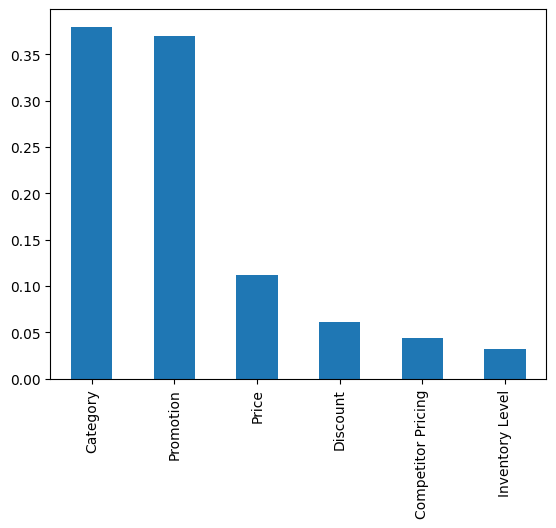

In [67]:
feature_importance.plot(kind='bar')

In [68]:
with open('../models/label_encoder.pkl','wb') as f:
    pickle.dump(label_encoders,f)

In [69]:
with open('../models/xgboost_demand_model.pkl','wb') as f:
    pickle.dump(best_model ,f)